<a href="https://colab.research.google.com/github/Sanika-tech123/Advanced-Machine-Learning-Practicals/blob/main/Q_Learning_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Iris.csv to Iris (2).csv
Q-TABLE MATRIX (first 20 rows):

[[  0.     0.     0.     0.     0.     0.  ]
 [ -3.03  -1.9   -2.97  -1.29   5.21  -8.52]
 [  0.43   4.15  -1.95   2.4   10.95  -7.24]
 [ -2.77  -3.27  -2.42  -2.68   6.54 -10.09]
 [ -6.51  -6.51  -6.52  -6.48 -12.86 -13.73]
 [  0.     0.     0.     0.     0.     0.  ]
 [ -6.28  -6.24  -6.24  -6.24 -12.09 -12.11]
 [ -5.4   -5.38  -5.39  -5.41 -11.01 -12.09]
 [ -2.24  -4.25  -4.2   -4.24 -12.37 -12.37]
 [ -3.65  -5.79  -5.88  -5.82 -13.61 -13.16]
 [  0.     0.     0.     0.     0.     0.  ]
 [ -3.91  -5.22  -5.22  -5.21 -11.88 -13.08]
 [ -6.35  -6.4   -6.34  -6.37 -13.93 -13.74]
 [ -5.7   -5.8   -5.81  -5.85 -13.21 -13.76]
 [ -6.46  -6.47  -6.45  -6.45 -14.15 -12.74]
 [  0.     0.     0.     0.     0.     0.  ]
 [ 14.98  17.37  14.11  16.46   7.46  20.  ]
 [  6.54  -1.36  -2.76  -0.5   -9.21  -2.18]
 [ 12.58   1.81  -1.71   4.65  -2.17  -0.18]
 [  7.93   0.39  -2.56  -1.77  -8.21  -1.24]]

BEST ACTION PER STATE (first 20):

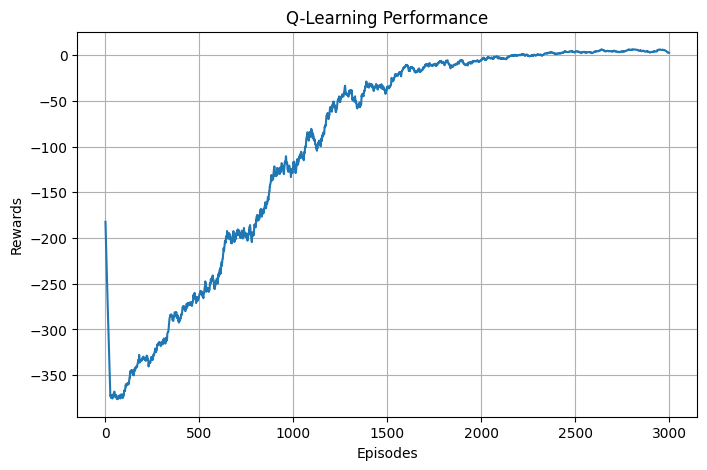

In [ ]:
!pip install gymnasium pandas -q

import numpy as np
import gymnasium as gym
import random
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

if "Iris.csv" in uploaded:
    df = pd.read_csv("Iris.csv")
    print(df.head())

env = gym.make("Taxi-v4")

state_space = env.observation_space.n
action_space = env.action_space.n

q_table = np.zeros((state_space, action_space))

alpha = 0.1
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.999
min_epsilon = 0.01

episodes = 3000
max_steps = 100

rewards = []

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0

    for step in range(max_steps):
        if random.uniform(0,1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, done, _, _ = env.step(action)

        q_table[state, action] = q_table[state, action] + alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state
        total_reward += reward

        if done:
            break

    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    rewards.append(total_reward)

print("Q-TABLE MATRIX (first 20 rows):\n")
print(np.round(q_table[:20], 2))

print("\nBEST ACTION PER STATE (first 20):\n")
print(np.argmax(q_table[:20], axis=1))

state, _ = env.reset()
total_reward = 0

print("\nAGENT PATH (NUMERIC):\n")

for step in range(30):
    action = np.argmax(q_table[state])
    next_state, reward, done, _, _ = env.step(action)

    print("Step:", step,
          "| State:", state,
          "| Action:", action,
          "| Reward:", reward)

    state = next_state
    total_reward += reward

    if done:
        break

print("\nFinal Reward:", total_reward)

def smooth(y, box_pts=50):
    box = np.ones(box_pts)/box_pts
    return np.convolve(y, box, mode='same')

plt.figure(figsize=(8,5))
plt.plot(smooth(rewards))
plt.xlabel("Episodes")
plt.ylabel("Rewards")
plt.title("Q-Learning Performance")
plt.grid()
plt.show()